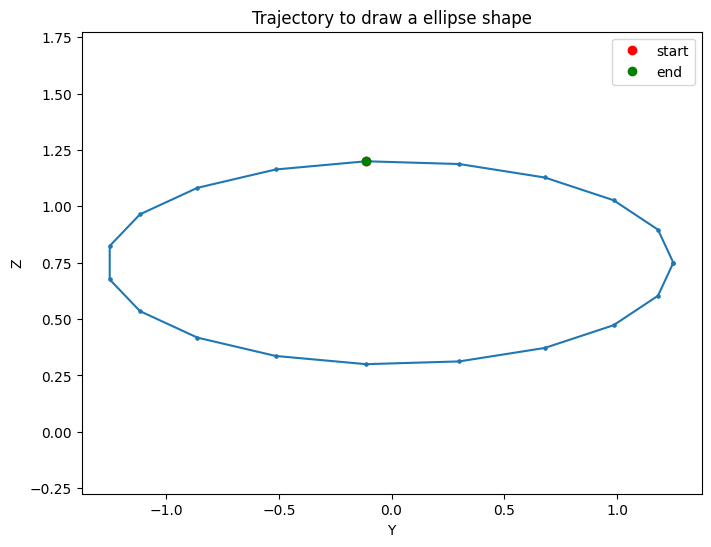

Shape of trajectory: (58, 3)


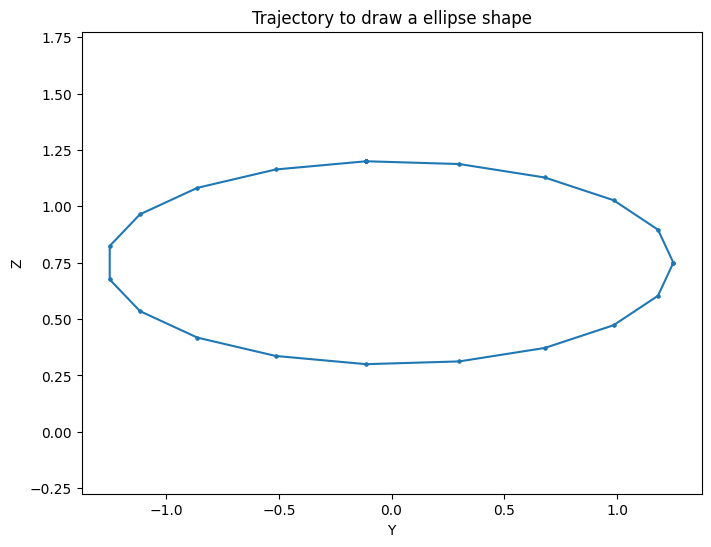

In [15]:
"Generate goal trajectory from shape"

import numpy as np
import matplotlib.pyplot as plt
import pickle

# select the shape
shape_type: str = "ellipse"  # Options: "heart", "ellipse", "infinity"

# fixed x-coordinate
x_fixed = 1.1

# parameter t (more points for smoother/slower trajectory)
t = np.linspace(0, 2 * np.pi, 20)

# depending on shape_type, define y and z
if shape_type == "heart":
    y = 16 * np.sin(t) ** 3
    z = 13 * np.cos(t) - 5 * np.cos(2 * t) - 2 * np.cos(3 * t) - np.cos(4 * t)
elif shape_type == "ellipse":
    a = 1
    b = 0.5
    y = a * np.cos(t)
    z = b * np.sin(t)
elif shape_type == "infinity":
    y = np.sin(t)
    z = np.sin(2 * t)
else:
    raise ValueError(f"Unknown shape_type: {shape_type}")

# find the index where y is closest to zero
start_idx = np.argmin(np.abs(y))

# rotate y and z arrays so that y starts from the point closest to y=0
y = np.roll(y, -start_idx)
z = np.roll(z, -start_idx)

# normalize the coordinates and scale to desired ranges
desired_range_y = [-1.25, 1.25]
desired_range_z = [0.3, 1.2]

y_min, y_max = y.min(), y.max()
z_min, z_max = z.min(), z.max()
y_normalized = (y - y_min) / (y_max - y_min)
y_scaled = y_normalized * (desired_range_y[1] - desired_range_y[0]) + desired_range_y[0]
z_normalized = (z - z_min) / (z_max - z_min)
z_scaled = z_normalized * (desired_range_z[1] - desired_range_z[0]) + desired_range_z[0]

# ensure the trajectory is closed by appending the starting point at the end if necessary
if y_scaled[0] != y_scaled[-1] or z_scaled[0] != z_scaled[-1]:
    # append the starting point to the end
    y_scaled = np.append(y_scaled, y_scaled[0])
    z_scaled = np.append(z_scaled, z_scaled[0])
# repeat first point n times
repeat_first_point_times = 5
y_scaled = np.insert(y_scaled, 0, [y_scaled[0]] * (repeat_first_point_times - 1))
z_scaled = np.insert(z_scaled, 0, [z_scaled[0]] * (repeat_first_point_times - 1))

# repeat the last point n times
repeat_last_point_times = 5
y_scaled = np.append(y_scaled, [y_scaled[-1]] * (repeat_last_point_times - 1))
z_scaled = np.append(z_scaled, [z_scaled[-1]] * (repeat_last_point_times - 1))

# repeat each point (slows down trajectory)
repeat_times = 2
y_repeated = np.repeat(y_scaled, repeat_times)
z_repeated = np.repeat(z_scaled, repeat_times)

# fixed x-coordinate array
x_points = np.full_like(y_repeated, x_fixed)

# plot the trajectory
plt.figure(figsize=(8, 6))
plt.plot(y_repeated, z_repeated, '-o', markersize=2)
# highlight start and end points
plt.plot(y_repeated[0], z_repeated[0], 'ro', label='start')
plt.plot(y_repeated[-1], z_repeated[-1], 'go', label='end')
plt.xlabel('Y')
plt.ylabel('Z')
plt.title(f'Trajectory to draw a {shape_type} shape')
plt.axis('equal')
plt.legend()
plt.show()

# save trajectory as array
trajectory = np.column_stack((x_points, y_repeated, z_repeated))
print("Shape of trajectory:", trajectory.shape)
with open(f"goal_traj/{shape_type}_large_sparse_new_goal_trajectory.pkl", "wb") as f:
    pickle.dump(trajectory, f)

# import and plot the trajectory to check
with open(f"goal_traj/{shape_type}_large_sparse_new_goal_trajectory.pkl", "rb") as f:
    trajectory = pickle.load(f)

plt.figure(figsize=(8, 6))
plt.plot(trajectory[:, 1], trajectory[:, 2], '-o', markersize=2)
plt.xlabel('Y')
plt.ylabel('Z')
plt.title(f'Trajectory to draw a {shape_type} shape')
plt.axis('equal')
plt.show()

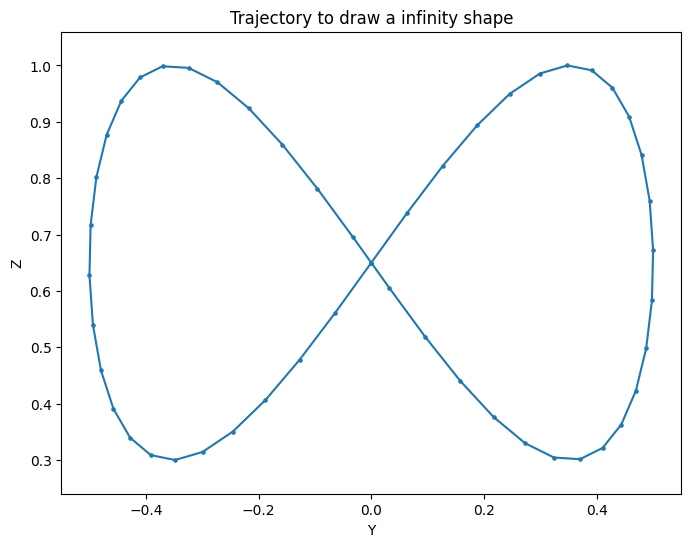

: 

In [ ]:
# import and plot the trajectory to check
import pickle
import matplotlib.pyplot as plt

shape_type = "infinity"
with open(f"goal_traj/{shape_type}_goal_trajectory.pkl", "rb") as f:
    trajectory = pickle.load(f)

plt.figure(figsize=(8, 6))
plt.plot(trajectory[:, 1], trajectory[:, 2], '-o', markersize=2)
plt.xlabel('Y')
plt.ylabel('Z')
plt.title(f'Trajectory to draw a {shape_type} shape')
plt.axis('equal')
plt.show()

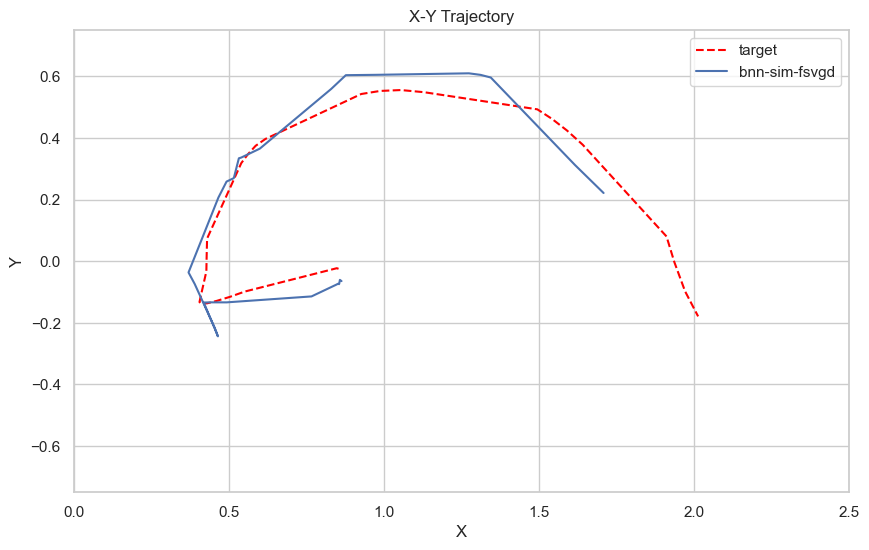

Shape of goal_trajectory: (30, 3)


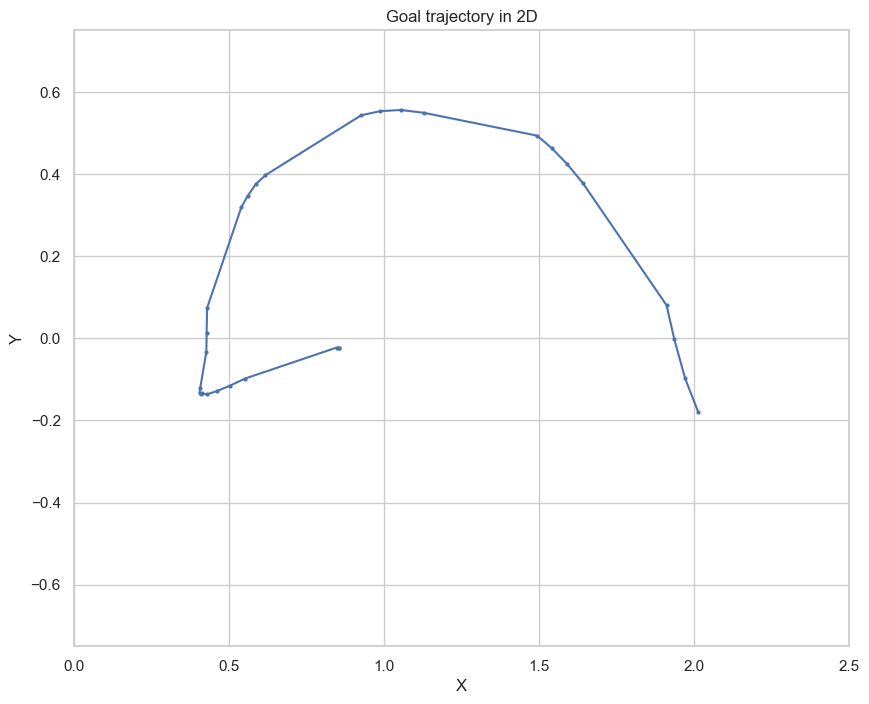

In [14]:
"Generate goal trajectory from collected data"

import numpy as np
import matplotlib.pyplot as plt
import pickle
import seaborn as sns

sns.set(style="whitegrid")

# pick the real trajectory
option = 0 # Options: 0, 1, 2

# load the real trajectory
real_traj_01 = "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/collected_data/test20241122-144932_traj_v00/brax_transitions.pickle"
real_traj_02 = "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/collected_data/test20241122-145039_traj_v01/brax_transitions.pickle"
real_traj_03 = "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/collected_data/test20241122-145157_traj_v02/brax_transitions.pickle"

if option == 0:
    real_traj = real_traj_01
elif option == 1:
    real_traj = real_traj_02
elif option == 2:
    real_traj = real_traj_03

with open(real_traj, "rb") as f:
    data = pickle.load(f)

observations = np.array([d.observation for d in data])

# first 300
observations = observations[:30]

ee_x_idx = 7
ee_y_idx = 8
ee_z_idx = 9

# real data
# file = "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/collected_data/test_ee_pos_testing_21xg6mx1_bnn-sim-fsvgd_13000_2_real_traj_0_test_v/brax_transitions.pickle"
file = "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/collected_data/test_shape_tracing_v7_uwi0v5mb_bnn-sim-fsvgd_4000_2_real_traj_0_test_v/brax_transitions.pickle"
with open(file, "rb") as f:
    data = pickle.load(f)

observations_real = np.array([d.observation for d in data])


# plot the trajectory in 2D
x_axis_limits = [-0, 2.5]
y_axis_limits = [-0.75, 0.75]
plt.figure(figsize=(10, 6))
plt.plot(observations[:, ee_x_idx], observations[:, ee_y_idx], '--', markersize=2, label='target', color='red')
plt.plot(observations_real[:, ee_x_idx], observations_real[:, ee_y_idx], '-', markersize=2, label='bnn-sim-fsvgd')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('X-Y Trajectory')
plt.legend()
plt.xlim(x_axis_limits)
plt.ylim(y_axis_limits)
plt.show()

# extract goal trajectory (only ee_x, ee_y, ee_z)
goal_trajectory = observations[:, [ee_x_idx, ee_y_idx, ee_z_idx]]
print("Shape of goal_trajectory:", goal_trajectory.shape)

# save goal trajectory
with open(f"goal_traj/real_traj_{option}_goal_trajectory.pkl", "wb") as f:
    pickle.dump(goal_trajectory, f)

# import and plot the trajectory to check
with open(f"goal_traj/real_traj_{option}_goal_trajectory.pkl", "rb") as f:
    trajectory = pickle.load(f)

plt.figure(figsize=(10, 8))
plt.plot(trajectory[:, 0], trajectory[:, 1], '-o', markersize=2)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Goal trajectory in 2D')
plt.xlim(x_axis_limits)
plt.ylim(y_axis_limits)
plt.show()

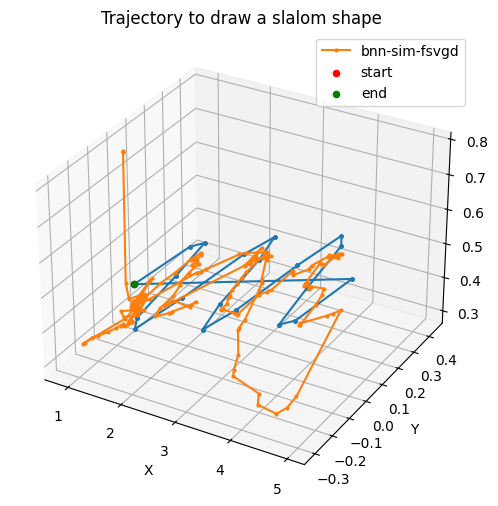

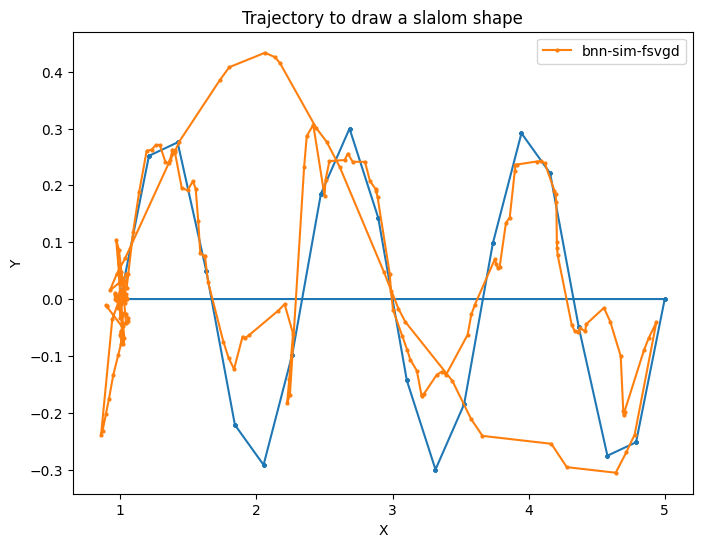

Shape of trajectory: (210, 3)


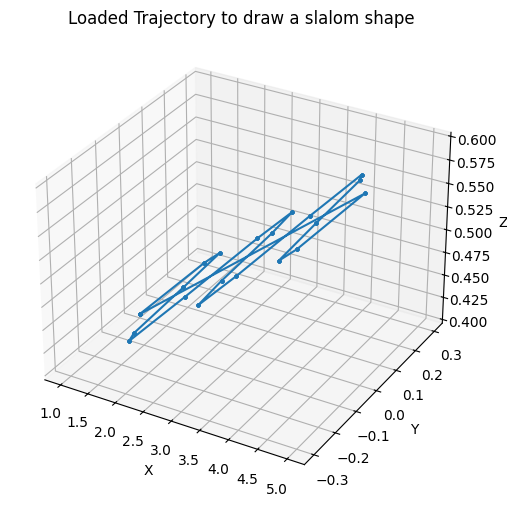

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy import signal
from mpl_toolkits.mplot3d import Axes3D

# select the shape
shape_type: str = "slalom"  # Options: "slalom", "zigzag"

# parameter t (more points for smoother/slower trajectory)
num_points = 20
t = np.linspace(0, 2 * np.pi, num_points)

# x limits
x_min, x_max = 1.0, 5.0

# z limits
z_min, z_max = 0.4, 0.6

# depending on shape_type, define x, y, and z
if shape_type == "slalom":
    # x varies from x_min to x_max
    x = np.linspace(x_min, x_max, num_points)
    # y oscillates
    num_oscillations = 3  # adjust as desired
    y_amplitude = 0.3  # adjust amplitude
    y = y_amplitude * np.sin(num_oscillations * t)
    # z varies smoothly
    z = np.linspace(z_min, z_max, num_points)
elif shape_type == "zigzag":
    # x varies from x_min to x_max
    x = np.linspace(x_min, x_max, num_points)
    # y varies as sawtooth function
    num_zigs = 5  # number of zigs
    y_amplitude = 1.0
    y = y_amplitude * signal.sawtooth(num_zigs * t, 0.5)  # 0.5 gives symmetric triangle wave
    # z varies smoothly
    z = np.linspace(z_min, z_max, num_points)
else:
    raise ValueError(f"Unknown shape_type: {shape_type}")

# Normalize y to desired range
desired_range_y = [-0.3, 0.3]
y_min, y_max = y.min(), y.max()
y_normalized = (y - y_min) / (y_max - y_min)
y_scaled = y_normalized * (desired_range_y[1] - desired_range_y[0]) + desired_range_y[0]

# Normalize z to desired range
z_min_current, z_max_current = z.min(), z.max()
z_normalized = (z - z_min_current) / (z_max_current - z_min_current)
z_scaled = z_normalized * (z_max - z_min) + z_min

# Normalize x to desired range
desired_range_x = [x_min, x_max]
x_min_current, x_max_current = x.min(), x.max()
x_normalized = (x - x_min_current) / (x_max_current - x_min_current)
x_scaled = x_normalized * (desired_range_x[1] - desired_range_x[0]) + desired_range_x[0]

# Ensure the trajectory is closed by appending the starting point at the end if necessary
if (x_scaled[0] != x_scaled[-1]) or (y_scaled[0] != y_scaled[-1]) or (z_scaled[0] != z_scaled[-1]):
    x_scaled = np.append(x_scaled, x_scaled[0])
    y_scaled = np.append(y_scaled, y_scaled[0])
    z_scaled = np.append(z_scaled, z_scaled[0])

# Repeat first point n times
repeat_first_point_times = 3
x_scaled = np.insert(x_scaled, 0, [x_scaled[0]] * (repeat_first_point_times - 1))
y_scaled = np.insert(y_scaled, 0, [y_scaled[0]] * (repeat_first_point_times - 1))
z_scaled = np.insert(z_scaled, 0, [z_scaled[0]] * (repeat_first_point_times - 1))

# Repeat the last point n times
repeat_last_point_times = 20
x_scaled = np.append(x_scaled, [x_scaled[-1]] * (repeat_last_point_times - 1))
y_scaled = np.append(y_scaled, [y_scaled[-1]] * (repeat_last_point_times - 1))
z_scaled = np.append(z_scaled, [z_scaled[-1]] * (repeat_last_point_times - 1))

# Repeat each point (slows down trajectory)
repeat_times = 5
x_repeated = np.repeat(x_scaled, repeat_times)
y_repeated = np.repeat(y_scaled, repeat_times)
z_repeated = np.repeat(z_scaled, repeat_times)

# robot trajectory
# file = "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/collected_data/test_shape_tracing_v7_bnn-sim-fsvgd_4000_3_slalom_bd4bgdzq_v/brax_transitions.pickle"
# file = "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/collected_data/test_shape_tracing_v7_bnn-sim-fsvgd_1000_3_slalom_f7w9z5xw_v/brax_transitions.pickle"
# file = "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/collected_data/test_shape_tracing_v7_bnn-sim-fsvgd_4000_3_slalom_bd4bgdzq_v_v1/brax_transitions.pickle"
# file = "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/collected_data/test_shape_tracing_v7_bnn-sim-fsvgd_4000_3_slalom_bd4bgdzq_v_v2/brax_transitions.pickle"
file = "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/collected_data/shape_tracing_v9/test_shape_tracing_v9_bnn-sim-fsvgd_8000_3_slalom_fast_more_new_qmvn3cn2_v/brax_transitions.pickle"
with open(file, "rb") as f:
    data = pickle.load(f)

observations_real = np.array([d.observation for d in data])

# Plot the trajectory in 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x_repeated, y_repeated, z_repeated, '-o', markersize=2)
ax.plot(observations_real[:, 7], observations_real[:, 8], observations_real[:, 9], '-o', markersize=2, label='bnn-sim-fsvgd')
# Highlight start and end points
ax.scatter(x_repeated[0], y_repeated[0], z_repeated[0], color='red', label='start')
ax.scatter(x_repeated[-1], y_repeated[-1], z_repeated[-1], color='green', label='end')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'Trajectory to draw a {shape_type} shape')
ax.legend()
plt.show()

# plot 2d view from top
plt.figure(figsize=(8, 6))
plt.plot(x_repeated, y_repeated, '-o', markersize=2)
plt.plot(observations_real[:, 7], observations_real[:, 8], '-o', markersize=2, label='bnn-sim-fsvgd')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Trajectory to draw a {shape_type} shape')
plt.legend()
plt.show()


# Save trajectory as array
trajectory = np.column_stack((x_repeated, y_repeated, z_repeated))
print("Shape of trajectory:", trajectory.shape)
with open(f"goal_traj/{shape_type}_fast_more_new_goal_trajectory.pkl", "wb") as f:
    pickle.dump(trajectory, f)

# Import and plot the trajectory to check
with open(f"goal_traj/{shape_type}_fast_more_new_goal_trajectory.pkl", "rb") as f:
    trajectory_loaded = pickle.load(f)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(trajectory_loaded[:, 0], trajectory_loaded[:, 1], trajectory_loaded[:, 2], '-o', markersize=2)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'Loaded Trajectory to draw a {shape_type} shape')
plt.show()